# Day 1

## Exercises


In this exercise you should implement everything including the tests
(e.g. the chi-square and KS tests) yourself. I recommend that you
also code routines for histogrammes yourself to better control
limits, but this is not strictly needed. Later, when your code is
working you are free to use builtin functions.

1. Write a program implementing a linear congruential generator
(LCG). Be sure that the program works correctly using only
integer representation.

- (a) Generate 10.000 (pseudo-) random numbers and present
these numbers in a histogramme (e.g. 10 classes).

- (b) Evaluate the quality of the generator by graphical
descriptive statistics (histogrammes, scatter plots) and
statistical tests- χ2,Kolmogorov-Smirnov, run-tests
preferably but not necessarily all 3, and correlation test for
some h-values.

- (c) Repeat (a) and (b) by experimenting with different values
of “a”, “b” and “M”. In the end you should have a decent
generator. Report at least one bad and your final choice.

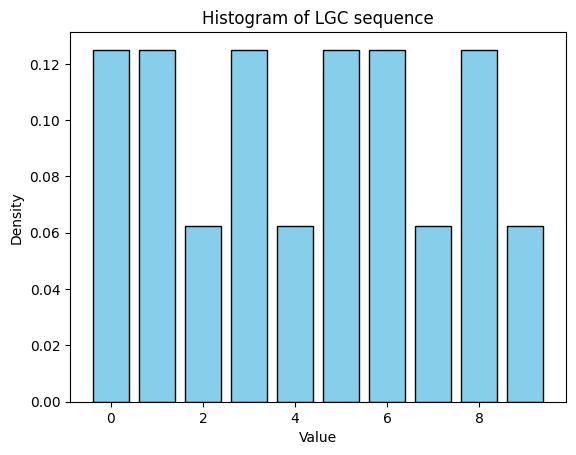

In [ ]:
import matplotlib.pyplot as plt
def LCG(x0, a, c, M, N):
    seq = []
    for _ in range(0, N-1):
        x = (a*x0 + c) % M
        x0 = x
        U = x/M
        seq.append(U)
    return seq

seq = LCG(3, 5, 1, 16, 10000)

counts = []
for i in range(10):
    count = sum(1 for x in seq if i/10 <= x < (i+1)/10)
    counts.append(count)
counts = [count/sum(counts) for count in counts]

plt.bar(range(10), counts, width=0.8, color="skyblue", edgecolor="black")
plt.title('Histogram of LGC sequence')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

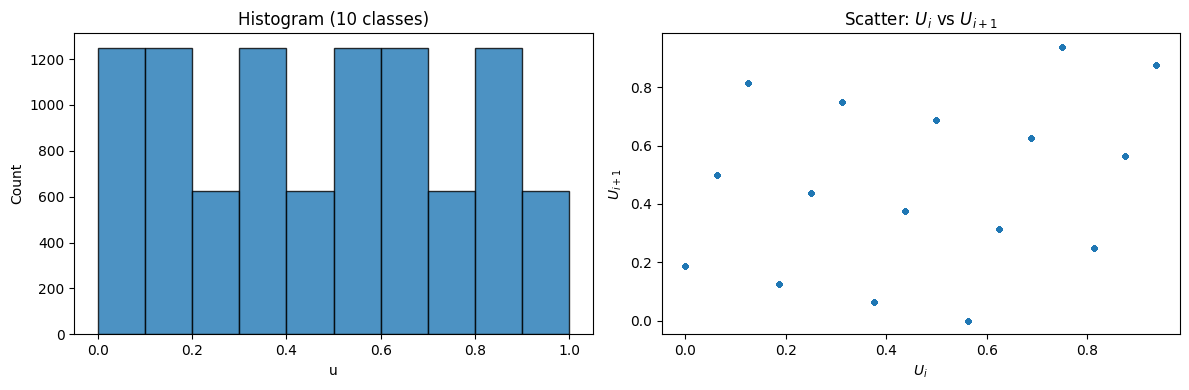

=== Chi-square (Uniform, 10 classes) ===
T = 937.0946, df = 9, p-value = 0
Observed counts: [1249, 1250, 625, 1250, 625, 1250, 1250, 625, 1250, 625]

=== Kolmogorov-Smirnov (Uniform) ===
D = 0.0625, p-value = 2.09649e-34

=== Runs test (above/below 0.5) ===
runs = 3750, z = -25.0125, p-value = 0


In [12]:
import numpy as np
from scipy.stats import chi2, kstest, norm

def chi_square_uniform_test(u, k=10):
    n = len(u)
    edges = np.linspace(0, 1, k + 1)
    obs, _ = np.histogram(u, bins=edges)
    exp = np.full(k, n / k)
    T = np.sum((obs - exp) ** 2 / exp)
    df = k - 1
    p = 1 - chi2.cdf(T, df)
    return T, df, p, obs, exp

def runs_test_above_below_median(u):
    signs = (u >= 0.5).astype(int)
    n1 = np.sum(signs == 1)
    n2 = np.sum(signs == 0)

    runs = 1 + np.sum(signs[1:] != signs[:-1])

    mu = (2 * n1 * n2) / (n1 + n2) + 1
    var = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / (((n1 + n2) ** 2) * (n1 + n2 - 1))
    z = (runs - mu) / np.sqrt(var)
    p = 2 * (1 - norm.cdf(abs(z)))
    return runs, z, p

N = 10_000
u = np.array(LCG(x0=1, a=5, c=3, M=16, N=N))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(u, bins=10, range=(0, 1), edgecolor='black', alpha=0.8)
ax[0].set_title("Histogram (10 classes)")
ax[0].set_xlabel("u")
ax[0].set_ylabel("Count")

ax[1].scatter(u[:-1], u[1:], s=8, alpha=0.35)
ax[1].set_title("Scatter: $U_i$ vs $U_{i+1}$")
ax[1].set_xlabel("$U_i$")
ax[1].set_ylabel("$U_{i+1}$")

plt.tight_layout()
plt.show()

T, df, p_chi2, obs, exp = chi_square_uniform_test(u, k=10)

D, p_ks = kstest(u, 'uniform')

runs, z_runs, p_runs = runs_test_above_below_median(u)

print("=== Chi-square (Uniform, 10 classes) ===")
print(f"T = {T:.4f}, df = {df}, p-value = {p_chi2:.6g}")
print("Observed counts:", obs.tolist())

print("\n=== Kolmogorov-Smirnov (Uniform) ===")
print(f"D = {D:.4f}, p-value = {p_ks:.6g}")

print("\n=== Runs test (above/below 0.5) ===")
print(f"runs = {runs}, z = {z_runs:.4f}, p-value = {p_runs:.6g}")

### Exercise (b) conclusion
The Chi-square test, tests whether the data is actually uniformly distributed. In this case it rejects the null-hypothesis that the sequence is uniformly distributed as there are some "classes" with significantly more counts than others. 

The Kolmogorov-Smirnov test, tests whether the emperical CDF follows the theoretical CDF of the uniform distribution. It also rejects the null-hypethesis, meaning that the empirical CDF does not follow the theoretical CDF. 

The Runs test, tests whether the sequence is randomly ordered or exhibits trends/dependencies. In this case the null-hypethesis that the sequence is randomly ordered is also rejected.

For (c) we perform a simple grid search over parameter combinations to find a combinations which satisfy that for all three tests the p-values must above 0.05.

In [35]:
import numpy as np
from scipy.stats import chi2, kstest, norm

def chi_square_uniform_test(u, k=10):
    n = len(u)
    edges = np.linspace(0, 1, k + 1)
    obs, _ = np.histogram(u, bins=edges)
    exp = np.full(k, n / k)
    T = np.sum((obs - exp) ** 2 / exp)
    df = k - 1
    p = 1 - chi2.cdf(T, df)
    return T, df, p, obs, exp

def runs_test_above_below_median(u):
    signs = (u >= 0.5).astype(int)
    n1 = np.sum(signs == 1)
    n2 = np.sum(signs == 0)

    runs = 1 + np.sum(signs[1:] != signs[:-1])

    mu = (2 * n1 * n2) / (n1 + n2) + 1
    var = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / (((n1 + n2) ** 2) * (n1 + n2 - 1))
    z = (runs - mu) / np.sqrt(var)
    p = 2 * (1 - norm.cdf(abs(z)))
    return runs, z, p

def lag_correlation_tests(u, h_values=(1, 2, 5, 10)):
    n = len(u)
    out = []
    for h in h_values:
        x = u[:-h]
        y = u[h:]
        r = np.corrcoef(x, y)[0, 1]
        z = r * np.sqrt(n - h)
        p = 2 * (1 - norm.cdf(abs(z)))
        out.append((h, r, z, p))
    return out

# ---- Generate and evaluate ----
def run_LCG_variations(x0, a, c, M, N):
    u = np.array(LCG(x0=x0, a=a, c=c, M=M, N=N))
    T, df, p_chi2, obs, exp = chi_square_uniform_test(u, k=10)

    D, p_ks = kstest(u, 'uniform')

    runs, z_runs, p_runs = runs_test_above_below_median(u)

    corr_results = lag_correlation_tests(u, h_values=(1, 2, 5, 10, 20))
    if p_chi2 > 0.05 and p_ks > 0.05 and p_runs > 0.05 and all(p > 0.05 for _, _, _, p in corr_results):
        return a, c, M
    
N = 10_000
A = [0,1,2,3,4,5,6,7,8,9, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
C = [0,1,2,3,4,5,6,7,8,9, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
M_list = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
for a in A:
    for c in C:
        for M in M_list:
            result = run_LCG_variations(x0=1, a=a, c=c, M=M, N=N)
            if result is not None:
                print(f"Found good parameters: a={result[0]}, c={result[1]}, M={result[2]}")
    

C:\Users\emilg\AppData\Local\Temp\ipykernel_15316\2727240372.py:23: RuntimeWarning: invalid value encountered in scalar divide
  z = (runs - mu) / np.sqrt(var)


Found good parameters: a=17, c=47, M=256
Found good parameters: a=37, c=11, M=1024
Found good parameters: a=37, c=23, M=1024
Found good parameters: a=37, c=37, M=512
Found good parameters: a=37, c=37, M=1024
Found good parameters: a=37, c=47, M=1024
Found good parameters: a=41, c=9, M=512
Found good parameters: a=41, c=11, M=512
Found good parameters: a=41, c=11, M=1024
Found good parameters: a=41, c=13, M=1024
Found good parameters: a=41, c=17, M=1024
Found good parameters: a=41, c=19, M=1024
Found good parameters: a=41, c=23, M=1024
Found good parameters: a=41, c=29, M=512
Found good parameters: a=41, c=29, M=1024
Found good parameters: a=41, c=31, M=512
Found good parameters: a=43, c=0, M=1024


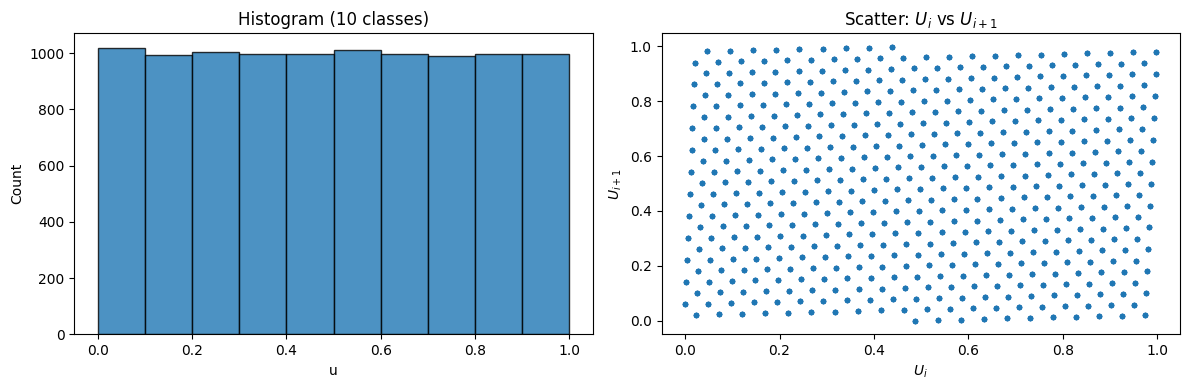

=== Chi-square (Uniform, 10 classes) ===
T = 0.6930, df = 9, p-value = 0.999878
Observed counts: [1019, 993, 1002, 996, 997, 1011, 998, 990, 995, 998]

=== Kolmogorov-Smirnov (Uniform) ===
D = 0.0029, p-value = 0.999996

=== Runs test (above/below 0.5) ===
runs = 5041, z = 0.8103, p-value = 0.417763

=== Lag correlation tests ===
h= 1: r=+0.00635, z=+0.635, p-value=0.525302
h= 2: r=-0.00389, z=-0.389, p-value=0.697308
h= 5: r=+0.00355, z=+0.355, p-value=0.722403
h=10: r=+0.01001, z=+1.000, p-value=0.31729
h=20: r=-0.00372, z=-0.371, p-value=0.710389


In [37]:
import numpy as np
from scipy.stats import chi2, kstest, norm

def chi_square_uniform_test(u, k=10):
    n = len(u)
    edges = np.linspace(0, 1, k + 1)
    obs, _ = np.histogram(u, bins=edges)
    exp = np.full(k, n / k)
    T = np.sum((obs - exp) ** 2 / exp)
    df = k - 1
    p = 1 - chi2.cdf(T, df)
    return T, df, p, obs, exp

def runs_test_above_below_median(u):
    signs = (u >= 0.5).astype(int)
    n1 = np.sum(signs == 1)
    n2 = np.sum(signs == 0)

    runs = 1 + np.sum(signs[1:] != signs[:-1])

    mu = (2 * n1 * n2) / (n1 + n2) + 1
    var = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / (((n1 + n2) ** 2) * (n1 + n2 - 1))
    z = (runs - mu) / np.sqrt(var)
    p = 2 * (1 - norm.cdf(abs(z)))
    return runs, z, p

def lag_correlation_tests(u, h_values=(1, 2, 5, 10)):
    n = len(u)
    out = []
    for h in h_values:
        x = u[:-h]
        y = u[h:]
        r = np.corrcoef(x, y)[0, 1]
        z = r * np.sqrt(n - h)
        p = 2 * (1 - norm.cdf(abs(z)))
        out.append((h, r, z, p))
    return out

# ---- Generate and evaluate ----
N = 10_000
a=41
c=31
M=512
u = np.array(LCG(x0=1, a=a, c=c, M=M, N=N))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(u, bins=10, range=(0, 1), edgecolor='black', alpha=0.8)
ax[0].set_title("Histogram (10 classes)")
ax[0].set_xlabel("u")
ax[0].set_ylabel("Count")

ax[1].scatter(u[:-1], u[1:], s=8, alpha=0.35)
ax[1].set_title("Scatter: $U_i$ vs $U_{i+1}$")
ax[1].set_xlabel("$U_i$")
ax[1].set_ylabel("$U_{i+1}$")

plt.tight_layout()
plt.show()

T, df, p_chi2, obs, exp = chi_square_uniform_test(u, k=10)

D, p_ks = kstest(u, 'uniform')

runs, z_runs, p_runs = runs_test_above_below_median(u)

corr_results = lag_correlation_tests(u, h_values=(1, 2, 5, 10, 20))

print("=== Chi-square (Uniform, 10 classes) ===")
print(f"T = {T:.4f}, df = {df}, p-value = {p_chi2:.6g}")
print("Observed counts:", obs.tolist())

print("\n=== Kolmogorov-Smirnov (Uniform) ===")
print(f"D = {D:.4f}, p-value = {p_ks:.6g}")

print("\n=== Runs test (above/below 0.5) ===")
print(f"runs = {runs}, z = {z_runs:.4f}, p-value = {p_runs:.6g}")

print("\n=== Lag correlation tests ===")
for h, r, z, p in corr_results:
    print(f"h={h:>2}: r={r:+.5f}, z={z:+.3f}, p-value={p:.6g}")

2. Apply a system available generator and perform the various
statistical tests you did under Part 1 point (b) for this
generator too.

Here we use the random() function from pythons random library which according to documentation uses the Mersenne Twister method (https://docs.python.org/3/library/random.html)

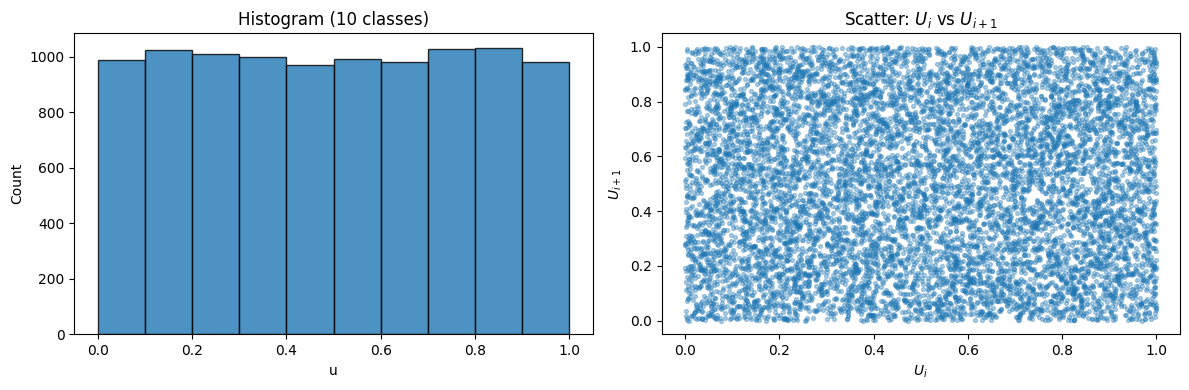

=== Chi-square (Uniform, 10 classes) ===
T = 4.1800, df = 9, p-value = 0.899171
Observed counts: [986, 1024, 1008, 1000, 971, 991, 981, 1026, 1032, 981]

=== Kolmogorov-Smirnov (Uniform) ===
D = 0.0052, p-value = 0.951197

=== Runs test (above/below 0.5) ===
runs = 5033, z = 0.6405, p-value = 0.521835


In [5]:
import random
N = 10_000
sequence = []
for _ in range(N):
    x = random.random()
    sequence.append(x)

u = np.array(sequence)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(u, bins=10, range=(0, 1), edgecolor='black', alpha=0.8)
ax[0].set_title("Histogram (10 classes)")
ax[0].set_xlabel("u")
ax[0].set_ylabel("Count")

ax[1].scatter(u[:-1], u[1:], s=8, alpha=0.35)
ax[1].set_title("Scatter: $U_i$ vs $U_{i+1}$")
ax[1].set_xlabel("$U_i$")
ax[1].set_ylabel("$U_{i+1}$")

plt.tight_layout()
plt.show()

T, df, p_chi2, obs, exp = chi_square_uniform_test(u, k=10)

D, p_ks = kstest(u, 'uniform')

runs, z_runs, p_runs = runs_test_above_below_median(u)

print("=== Chi-square (Uniform, 10 classes) ===")
print(f"T = {T:.4f}, df = {df}, p-value = {p_chi2:.6g}")
print("Observed counts:", obs.tolist())

print("\n=== Kolmogorov-Smirnov (Uniform) ===")
print(f"D = {D:.4f}, p-value = {p_ks:.6g}")

print("\n=== Runs test (above/below 0.5) ===")
print(f"runs = {runs}, z = {z_runs:.4f}, p-value = {p_runs:.6g}")